<h3 style="color:teal;text-align:center">⌞Timestamp Alignment⌟</h3>

<h4>• Data concatenation</h4>

In [14]:
import pandas as pd

TS_COL = "timestamp(UTC)"

df1 = pd.read_csv("dataset/AQUAIR_1.csv")
df2 = pd.read_csv("dataset/AQUAIR_2.csv")

df = pd.concat([df1, df2], ignore_index=True)
print(f"New dataset size : {df.shape}")

New dataset size : (23856, 8)


<h4>• Timestamps parsing</h4>

In [15]:
from datetime import timedelta, timezone

# Parse timestamps as UTC (handles YYYY-MM-DD HH:MM:SS)
parsed = pd.to_datetime(df[TS_COL], utc=True, errors="coerce")

# Handle the remaining M/D/YYYY H:MM
missing = parsed.isna()
if missing.any():
  parsed.loc[missing] = pd.to_datetime(
    df.loc[missing, TS_COL],
    format="%m/%d/%Y %H:%M",
    utc=True,
    errors="coerce",
  )

df[TS_COL] = parsed
df = df.dropna(subset=[TS_COL])
df["timestamp(UTC+1)"] = df[TS_COL].dt.tz_convert(timezone(timedelta(hours=1)))
df = df.drop("timestamp(UTC)", axis=1)

df["timestamp(UTC+1)"].head()

0   2024-10-14 13:55:00+01:00
1   2024-10-14 14:00:00+01:00
2   2024-10-14 14:05:00+01:00
3   2024-10-14 14:10:00+01:00
4   2024-10-14 14:15:00+01:00
Name: timestamp(UTC+1), dtype: datetime64[ns, UTC+01:00]

<h4>• Process 5min gaps</h4>

In [ ]:
# Resample to a 5-minute grid
df_idx = df.set_index("timestamp(UTC+1)").sort_index()

numeric_cols = df_idx.select_dtypes(include="number").columns.tolist()
other_cols = [col for col in df_idx.columns if col not in numeric_cols]

agg_map = {col: "mean" for col in numeric_cols}
agg_map.update({col: "first" for col in other_cols})

# Resample
grid = (
  df_idx.resample("5min", label="left", closed="left", origin="start_day")
  .agg(agg_map)
)

# Scientific Range Tests (AQUAIR Physical Operating Envelope)
grid.loc[(grid['co2'] < 400) | (grid['co2'] > 5000), 'co2'] = pd.NA
grid.loc[(grid['pm25'] > 1000), 'pm25'] = pd.NA
grid.loc[(grid['pm10'] > 1000), 'pm10'] = pd.NA
grid.loc[(grid['temp'] < -40) | (grid['temp'] > 125), 'temp'] = pd.NA

# Outlier Detection: Hampel Filter
for col in ["co2", "voc", "pm25", "pm10"]:
  rolling_median = grid[col].rolling(window=7, center=True).median()
  rolling_std = grid[col].rolling(window=7, center=True).std()
  outliers = (grid[col] - rolling_median).abs() > (3 * rolling_std)

  # Replace detected outliers with the local median
  grid.loc[outliers, col] = rolling_median

# Interpolation
grid[numeric_cols] = grid[numeric_cols].interpolate(
  method="time",
  limit=2,
  limit_direction="both"
)

# Index to column
grid = grid.reset_index()

# Format timestamp string
grid["timestamp(UTC+1)"] = (
  grid["timestamp(UTC+1)"]
  .dt.strftime("%Y-%m-%dT%H:%M:%S%z")
  .str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)
)

output_path = "dataset/aquair_merged_5min.csv"
grid.to_csv(output_path, index=False)

print(grid.head())
print(f"5-min rows: {len(grid)} -> saved to {output_path}")

            timestamp(UTC+1)  score  temp  humid    co2    voc  pm25  pm10
0  2024-10-14T13:55:00+01:00   86.8  19.0   59.8  688.6  320.4   5.3   6.3
1  2024-10-14T14:00:00+01:00   83.0  18.2   60.6  646.7  185.0   8.0   9.0
2  2024-10-14T14:05:00+01:00   82.2  17.8   61.4  629.4  123.0   4.0   5.0
3  2024-10-14T14:10:00+01:00   76.6  16.8   64.3  568.4   79.4   2.8   3.8
4  2024-10-14T14:15:00+01:00   73.6  17.0   65.5  551.2   57.8  13.0  14.2
5-min rows: 25180 -> saved to dataset/aquair_merged_5min.csv


<h4>• Verification + EDA</h4>

--- Summary Statistics ---
                co2          pm25
count  23870.000000  23870.000000
mean    1142.390162     18.274335
std      803.724948     20.964752
min      400.000000      0.000000
25%      442.600000      2.800000
50%      757.600000     12.200000
75%     1851.725000     28.200000
max     3703.600000    505.200000

--- Missing Values Check ---
score    1310
temp     1310
humid    1310
co2      1310
voc      1310
pm25     1310
pm10     1310
dtype: int64


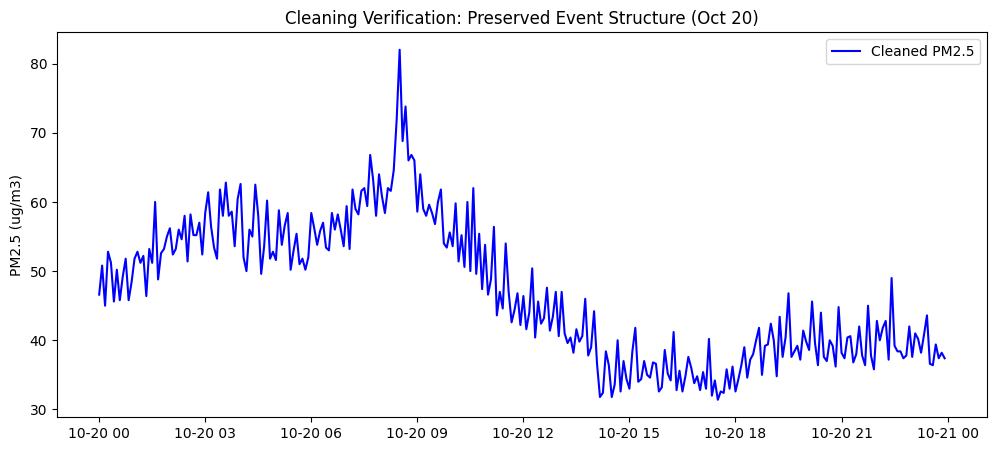

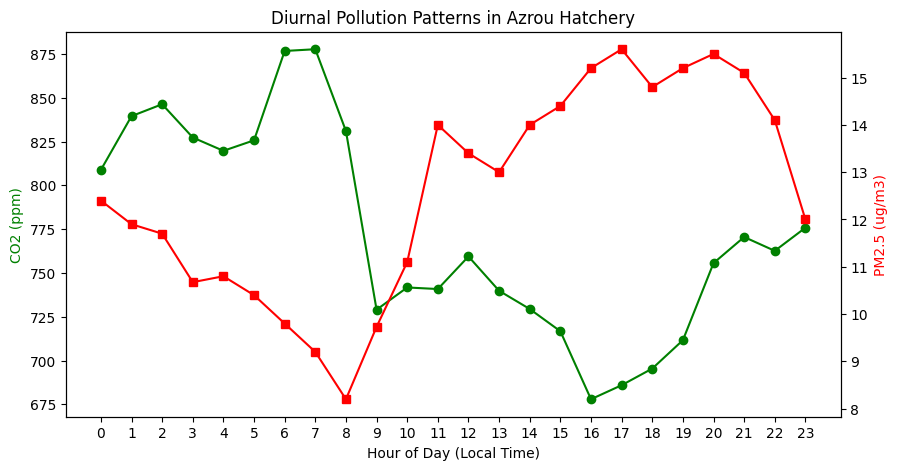

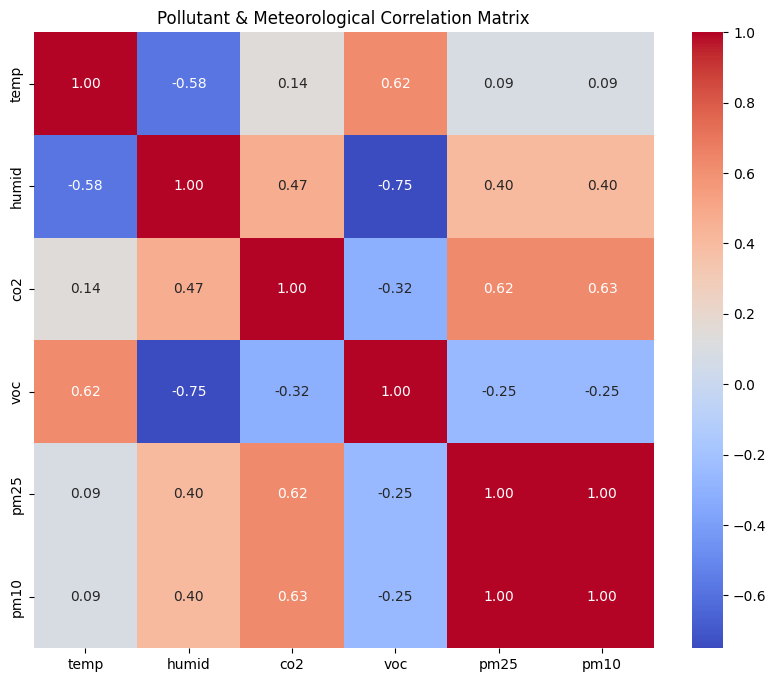

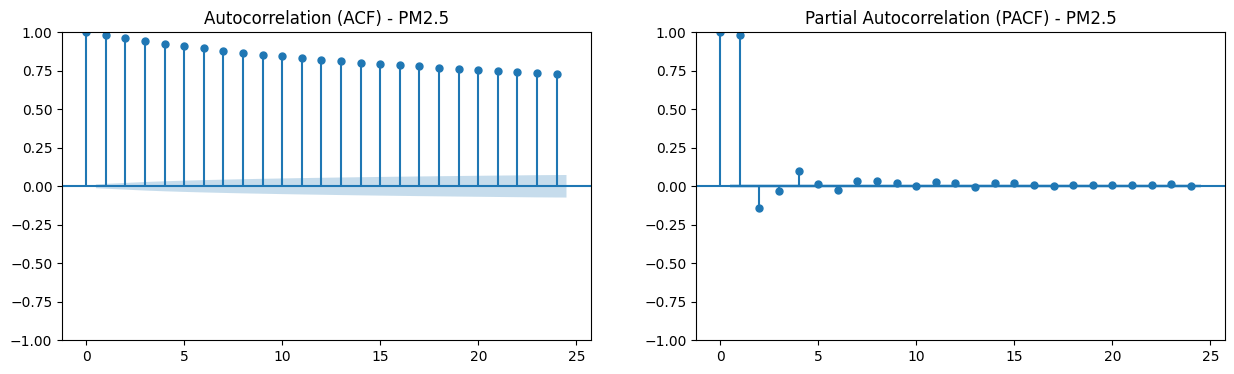

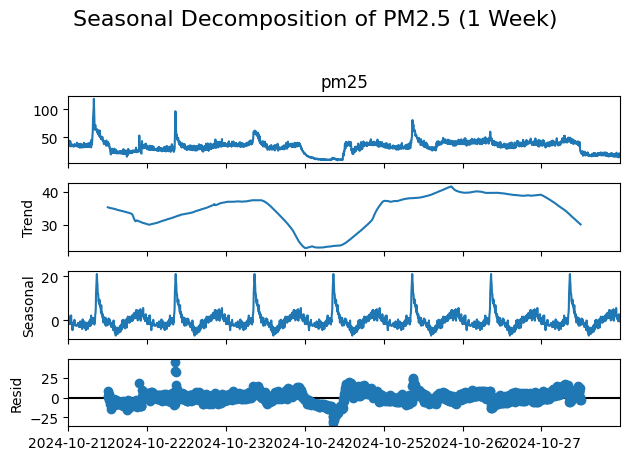

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Load your analysis-ready data
# Ensure 'timestamp(UTC+1)' is parsed as a datetime and set as index
df = pd.read_csv("dataset/aquair_merged_5min.csv", parse_dates=["timestamp(UTC+1)"])
df.set_index("timestamp(UTC+1)", inplace=True)

# --- STEP 1: CLEANING VERIFICATION ---

# Summary statistics
print("--- Summary Statistics ---")
print(df[['co2', 'pm25']].describe())

# Check gap consistency: Ensure the 5-day December gap is still NaN
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# Plot Raw vs Filtered
plt.figure(figsize=(12, 5))
sample_window = df.loc['2024-10-20']
plt.plot(sample_window.index, sample_window['pm25'], label='Cleaned PM2.5', color='blue')
plt.title('Cleaning Verification: Preserved Event Structure (Oct 20)')
plt.ylabel('PM2.5 (ug/m3)')
plt.legend()
plt.show()

# --- STEP 2: DIURNAL PROFILING (Feeding-Time Peaks) ---

df['hour'] = df.index.hour
hourly_trends = df.groupby('hour')[['co2', 'pm25', 'pm10']].median()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(hourly_trends.index, hourly_trends['co2'], color='green', marker='o', label='Median CO2')
ax2.plot(hourly_trends.index, hourly_trends['pm25'], color='red', marker='s', label='Median PM2.5')

ax1.set_xlabel('Hour of Day (Local Time)')
ax1.set_ylabel('CO2 (ppm)', color='green')
ax2.set_ylabel('PM2.5 (ug/m3)', color='red')
plt.title('Diurnal Pollution Patterns in Azrou Hatchery')
plt.xticks(range(0, 24))
plt.show()

# --- STEP 3: MULTI-VARIABLE CORRELATION ---

plt.figure(figsize=(10, 8))
sns.heatmap(df[['temp', 'humid', 'co2', 'voc', 'pm25', 'pm10']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pollutant & Meteorological Correlation Matrix')
plt.show()

# --- STEP 4: LAG & AUTOCORRELATION ANALYSIS ---

# Drop NaNs temporarily just for the ACF/PACF plots
temp_clean = df['pm25'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(temp_clean, lags=24, ax=ax1)
plot_pacf(temp_clean, lags=24, ax=ax2)
ax1.set_title('Autocorrelation (ACF) - PM2.5')
ax2.set_title('Partial Autocorrelation (PACF) - PM2.5')
plt.show()

# --- STEP 5: TIME-SERIES DECOMPOSITION ---

# Decompose a 1-week period to see seasonality vs noise
weekly_sample = df['pm25'].loc['2024-10-21':'2024-10-27'].interpolate(method='linear')
result = seasonal_decompose(weekly_sample, model='additive', period=288) # 288 steps = 24 hours

result.plot()
plt.suptitle('Seasonal Decomposition of PM2.5 (1 Week)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()